Pipeline 에 따로별칭 줘야함~!

종속변수가 거의 2배 이상 차이나는 상황

스케일링 이후에 불균형 처리로 들어감

트리계열은 스케일링불필요하지만
불균혀 해소 처리 (거리기반) 가 포함되면 트리도 스케일링 필수


최근접기반..k neighbor> 엘보우 포인트르......

데이터 증강은 훈련 데이터에만 적용해야함



# [LAB 09] 지도학습 > 분류 > 06.클래스 불균형 처리
## #01.준비작업

In [12]:

# =====================================================
# 기본 라이브러리
# =====================================================
from hossam import *

import pandas as pd
from pandas import DataFrame, Series, concat, merge
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from itertools import product


# =====================================================
# sklearn 공통
# =====================================================
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# =====================================================
# 선형 모델
# =====================================================
from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression,
    Ridge,
    Lasso,
    SGDClassifier,
    SGDRegressor
)


# =====================================================
# 기타 분류 모델
# =====================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# =====================================================
# 성능 평가 지표
# =====================================================
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score
)


# =====================================================
# SHAP 분석
# =====================================================
import shap



# =====================================================
# 클래스 불균형 해결 
# =====================================================
from imblearn.pipeline import Pipeline as imbPipeline

# 클래스 불균형 해결 라이브러리
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline


### [2] 앞서 정의한 함수
- hs_cls_bin_socres

In [3]:
def hs_cls_bin_scores(estimator, x_test, y_test):

    # 피_양성 확률
    y_pred_proba = estimator.predict_proba(x_test)

    # 1로 분류될 확률
    y_pred_proba_1 = estimator.predict_proba(x_test)[:, 1]

    # 예측값
    y_pred = estimator.predict(x_test)

    # 의사결정계수 (Pseudo R²)
    log_loss_test = -log_loss(y_test, y_pred_proba, normalize=False)
    y_null = np.ones_like(y_test) * y_test.mean()
    log_loss_null = -log_loss(y_test, y_null, normalize=False)
    pseudo_r2 = 1 - (log_loss_test / log_loss_null)

    # 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    ((TN, FP), (FN, TP)) = cm

    # 클래스 이름
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # auc score
    auc = roc_auc_score(y_test, y_pred_proba_1)

    score_df = DataFrame({
        "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
        "정밀도(Precision)": [precision_score(y_test, y_pred)],
        "재현율(Recall,tpr)": [recall_score(y_test, y_pred)],
        "위양성률(Fallout,fpr)": [FP / (TN + FP)],
        "특이성(TNR)": [1 - (FP / (TN + FP))],
        "F1-Score": [f1_score(y_test, y_pred)],
        "AUC": [auc]
    }, index=[classname])

    # ------------------------------
    # ROC 곡선 그리기
    # ------------------------------

    roc_fpr, roc_tpr, thresholds = roc_curve(y_test, y_pred_proba_1)

    # 1) 그래프 초기화
    my_dpi = 100  # 그래프 해상도

    width_px = 1000   # 그래프 가로 크기
    height_px = 900   # 그래프 세로 크기
    rows = 1          # 그래프 행 수
    cols = 1          # 그래프 열 수

    figsize = (width_px / my_dpi, height_px / my_dpi)
    fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    # 2) LinePlot 그리기
    sb.lineplot(x=roc_fpr, y=roc_tpr)
    sb.lineplot(x=[0, 1], y=[0, 1], color='red', linestyle=":", alpha=0.5)
    plt.fill_between(x=roc_fpr, y1=roc_tpr, alpha=0.1)

    # 3) 그래프 꾸미기
    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC={auc:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # 4) 출력
    plt.tight_layout()
    plt.show()
    plt.close()

    return score_df


### [3] 데이터 가져오기

In [4]:
origin = load_data('pima_indians_diabetes_preprocessed')
origin.head()

캐글에서 제공하는 pima_indians_diabetes의 전처리 완료 버전(결측치 정제+로그변환) (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.946,5.004,72,3.584,4.836,3.544,0.487,3.932,1
1,0.693,4.454,66,3.401,4.836,3.318,0.301,3.466,0
2,2.197,5.215,64,3.401,4.836,3.190,0.514,3.497,1
3,0.693,4.500,66,3.178,4.554,3.371,0.154,3.091,0
4,0.000,4.927,40,3.584,5.130,3.786,1.190,3.526,1


### [4] 훈련,검증 데이터 분리

In [5]:
df = origin

# 종속변수는 정수형으로 변환해야 한다.
df['Outcome'] = df['Outcome'].astype('int')

yname = "Outcome"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((614, 8), (154, 8), (614,), (154,))

## #02.RandomForest 분류 모형 적합

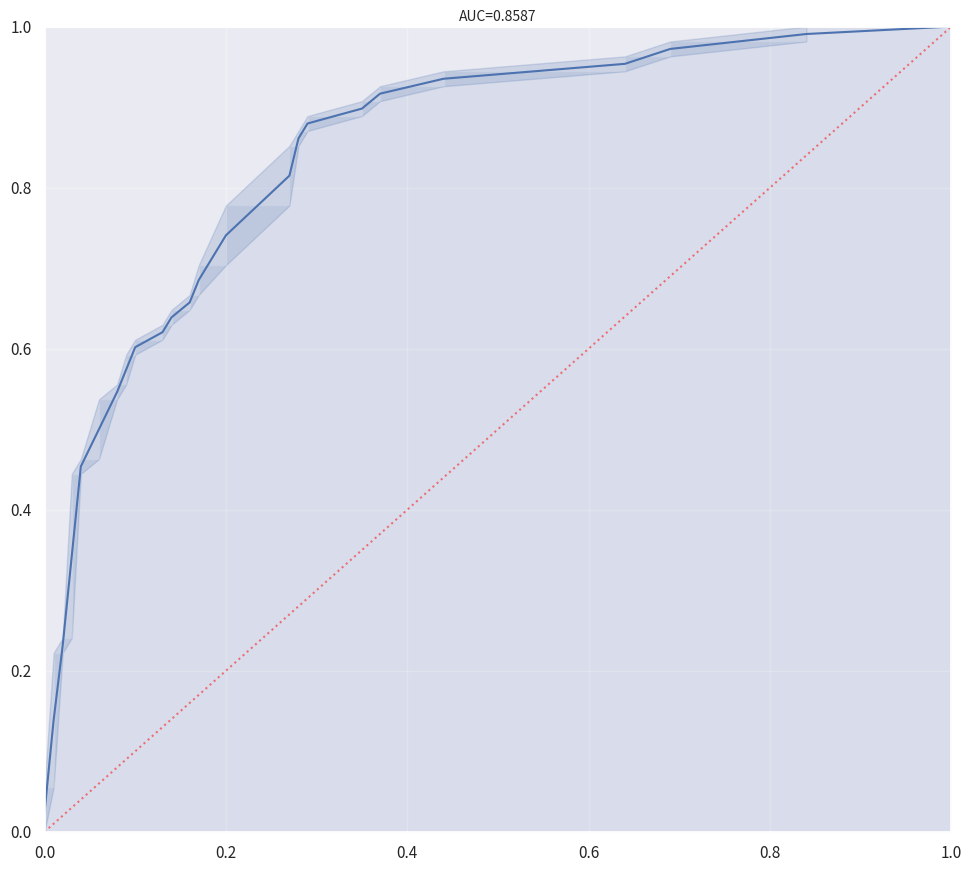

CPU times: total: 2.28 s
Wall time: 28.6 s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
RandomForestClassifier,0.747,0.609,0.778,0.270,0.730,0.683,0.859


In [6]:
%%time

rf_cls_pipe = Pipeline([
    (
        "model",
        RandomForestClassifier(
            random_state=52,
            n_jobs=-1,
        ),
    )
])

rf_cls_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}

rf_cls_gs = GridSearchCV(
    estimator=rf_cls_pipe,
    param_grid=rf_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

rf_cls_gs.fit(x_train, y_train)

rf_cls_estimator = rf_cls_gs.best_estimator_

rf_cls_score_df = hs_cls_bin_scores(
    rf_cls_estimator,
    x_test,
    y_test
)

rf_cls_score_df


## #03.데이터 불균형의 이해
### [1] 종속변수 비율

In [7]:
origin['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

### [2] 데이터 불균형이란?
- 분류 문제에서 종속변수의 클래스 비율이 크게 차이나는 상태

#### 📌 데이터 불균형 상황

- 한 클래스가 압도적으로 많음  
- 다른 클래스는 매우 적음  
- 모델이 특정 클래스에 편향될 위험 존재  

---

#### 📌 데이터 불균형 시 문제점

- **Accuracy가 왜곡됨**
  - 예: 한 클래스가 95%인 경우  
  - 모두 0으로 예측해도 Accuracy = 95%

- **소수 클래스 Recall 급감**
  - 중요한 양성 데이터를 놓칠 가능성 증가  

---

#### 📌 데이터 불균형이 문제가 되는 사례

- 사기 탐지  
- 질병 진단  
- 고장 탐지  
- 고객 이탈 예측  


## #04. 데이터 불균형의 해결
- 불균형 해소 처리가 포함될 경우, 트리계열이더라도 스케일링 필수

### [1] Random Under Sampling
- 다수 클래스 일부 제거
  - 학습 속도 빠름
  - 예측 성능 감소

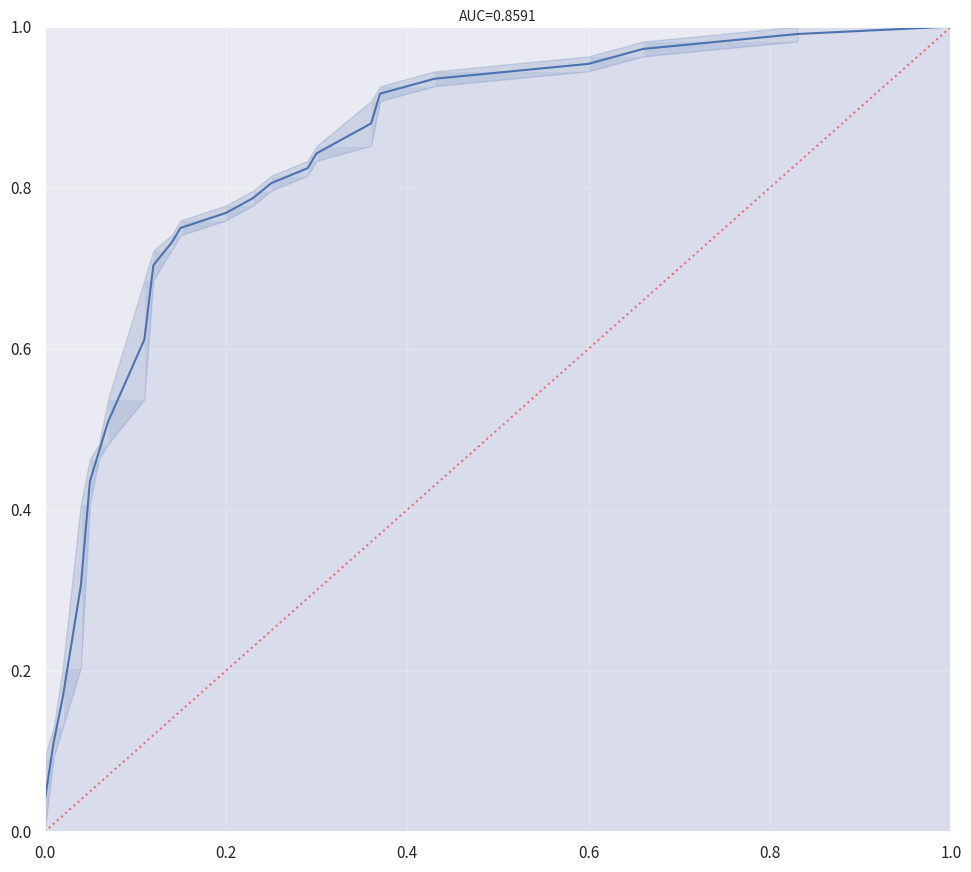

,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
기본 RF,0.747,0.609,0.778,0.270,0.730,0.683,0.859
언더샘플링 RF,0.760,0.620,0.815,0.270,0.730,0.704,0.859


In [8]:
# -----------------------------
# Random UnderSampling + RandomForest
# -----------------------------

from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.under_sampling import RandomUnderSampler

rus_pipe = imbPipeline([
    ("scale", StandardScaler()),
    ("rus", RandomUnderSampler(random_state=52)),
    ("model", RandomForestClassifier(random_state=52, n_jobs=-1))
])

rus_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}

rus_gs = GridSearchCV(
    estimator=rus_pipe,
    param_grid=rus_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

rus_gs.fit(x_train, y_train)

rus_estimator = rus_gs.best_estimator_

rus_score_df = hs_cls_bin_scores(
    rus_estimator,
    x_test,
    y_test
)

# 기존 RF 모델과 비교
rdf = concat([rf_cls_score_df, rus_score_df], axis=0)
rdf.index = ["기본 RF", "언더샘플링 RF"]

rdf


### [2] Random Over Sampling
- 소수 클래스 데이터를 무작위 복제
  - 데이터 중복 발생
  - 과적합 위험 높음
- 단순한 방식

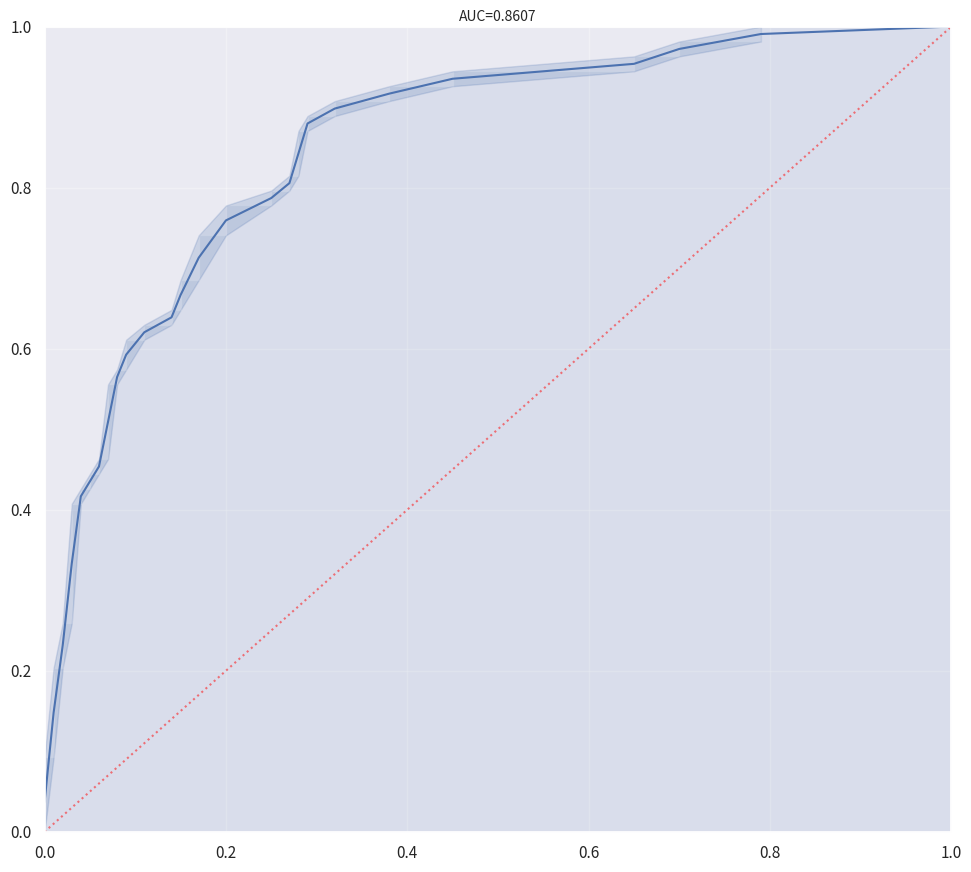

,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
기본 RF,0.747,0.609,0.778,0.270,0.730,0.683,0.859
언더샘플링 RF,0.760,0.620,0.815,0.270,0.730,0.704,0.859
오버샘플링 RF,0.760,0.620,0.815,0.270,0.730,0.704,0.861


In [9]:
# -----------------------------
# Random OverSampling + RandomForest
# -----------------------------

from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.over_sampling import RandomOverSampler

ros_pipe = imbPipeline([
    ("scale", StandardScaler()),
    ("ros", RandomOverSampler(random_state=52)),
    ("model", RandomForestClassifier(random_state=52, n_jobs=-1))
])

ros_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}

ros_gs = GridSearchCV(
    estimator=ros_pipe,
    param_grid=ros_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

ros_gs.fit(x_train, y_train)

ros_estimator = ros_gs.best_estimator_

ros_score_df = hs_cls_bin_scores(
    ros_estimator,
    x_test,
    y_test
)

# -----------------------------
# 기본 RF vs 언더샘플링 vs 오버샘플링 비교
# -----------------------------

rdf = concat([rf_cls_score_df, rus_score_df, ros_score_df], axis=0)
rdf.index = ["기본 RF", "언더샘플링 RF", "오버샘플링 RF"]

rdf


### [3] SMOTE
- 최근접 이웃 (KNN) 기반 가상 샘플 생성
- 단순 복제가 아닌 보간 수행
- 가장 기본적인 데이터 증강 방법

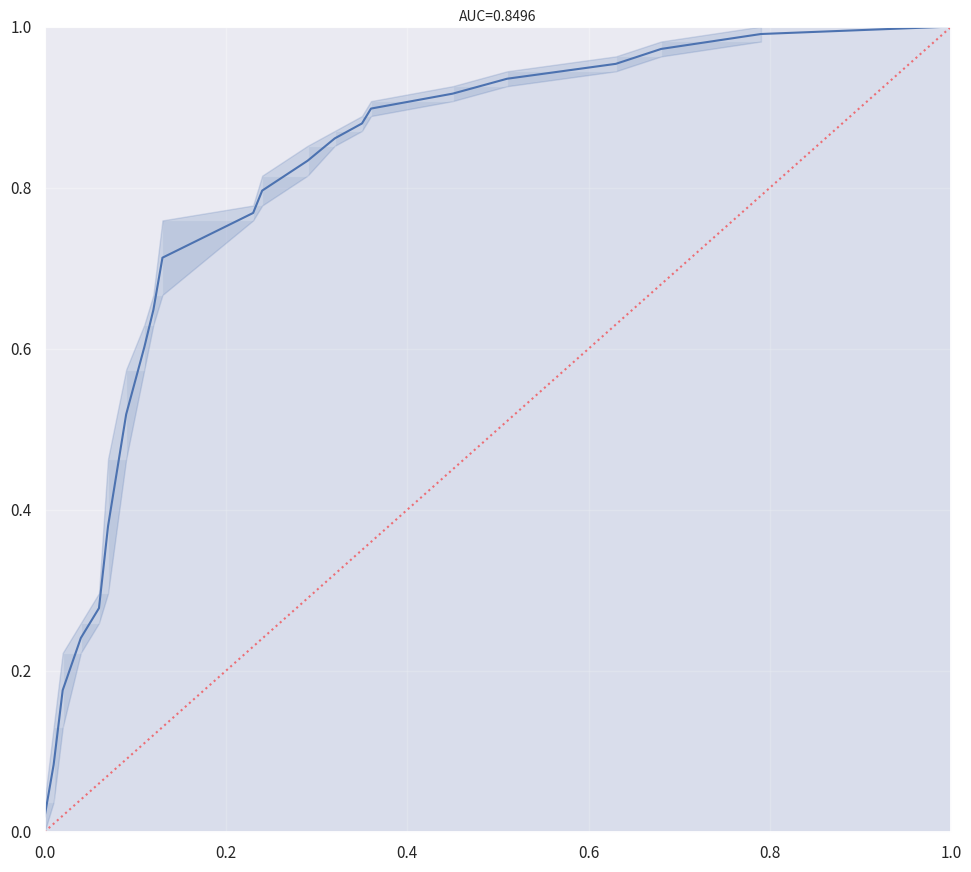

,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
기본,0.747,0.609,0.778,0.270,0.730,0.683,0.859
언더샘플링,0.760,0.620,0.815,0.270,0.730,0.704,0.859
오버샘플링,0.760,0.620,0.815,0.270,0.730,0.704,0.861
SMOTE,0.766,0.629,0.815,0.260,0.740,0.710,0.850


In [14]:
sm_pipe = imbPipeline([
    ('scale', StandardScaler()),
    ('sm', SMOTE(random_state=52, k_neighbors=5)),
    ('model', RandomForestClassifier(random_state=52, n_jobs=-1))
])

sm_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}

sm_gs = GridSearchCV(
    estimator=sm_pipe,
    param_grid=sm_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

sm_gs.fit(x_train, y_train)

rf_cls_estimator = sm_gs.best_estimator_

sm_score_df = hs_cls_bin_scores(
    rf_cls_estimator,
    x_test,
    y_test
)

rdf = concat([rf_cls_score_df, rus_score_df, ros_score_df, sm_score_df], axis=0)
rdf.index = ['기본', '언더샘플링', '오버샘플링', 'SMOTE']

rdf
